In [11]:
import sys
import os
import pandas as pd 

sys.path.append(os.path.abspath('..'))

In [12]:
from src.entrada_saida import carregar_dados_brutos
from src.visualizacao import configurar_estilo, plotar_sazonalidade, plotar_ranking_cidades
df = carregar_dados_brutos("../data/RECLAMEAQUI_HAPVIDA_LIMPO.csv")

# Análise Descritiva Preliminar

## Frequência por STATUS

In [13]:

display(df['STATUS'].value_counts().reset_index(name='TOTAL'))

,STATUS,TOTAL
0,Não respondida,639
1,Respondida,271
2,Resolvido,67
3,Em réplica,36
4,Não resolvido,3


## Tamanho das reclamações

In [14]:
df['DESCRICAO'].str.len().describe()

count     1016.000000
mean       455.070866
std        514.344278
min          7.000000
25%        212.750000
50%        354.500000
75%        573.500000
max      12800.000000
Name: DESCRICAO, dtype: float64

## Frequência por categoria

In [15]:
display(df['TIPO_SERVICO'].value_counts().reset_index(name='TOTAL'))

,TIPO_SERVICO,TOTAL
0,ATENDIMENTO,388
1,AGENDAMENTO,271
2,EXAMES / PROCEDIMENTOS,117
3,OUTROS,90
4,FINANCEIRO,72
5,AUTORIZAÇÃO,45
6,ADMINISTRATIVO,29
7,ESTRUTURA / REDE,3
8,INFORMAÇÃO,1


## Sazonalidade

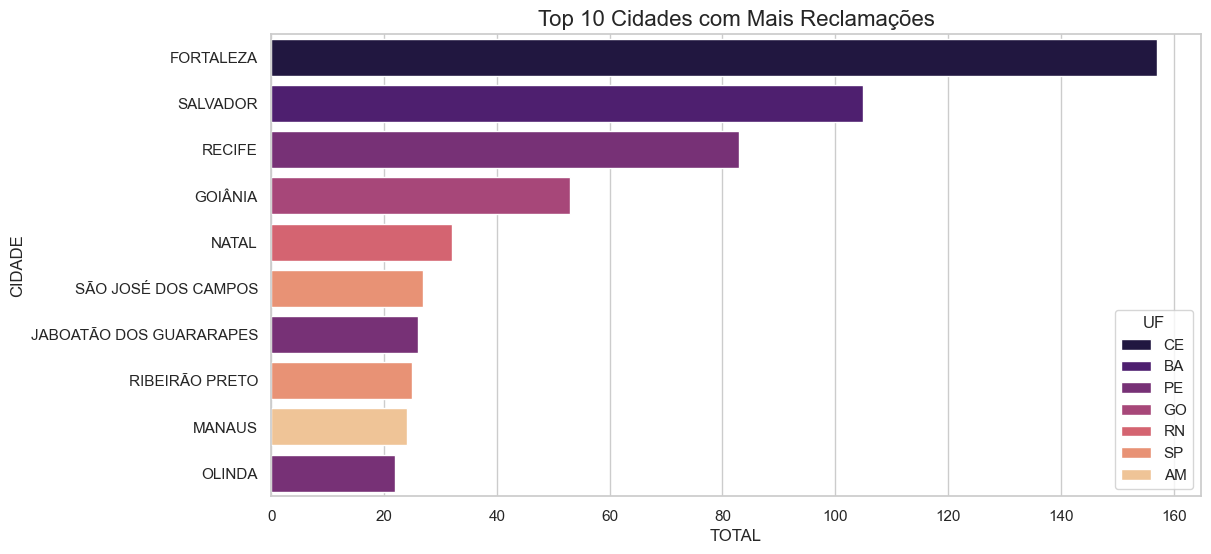

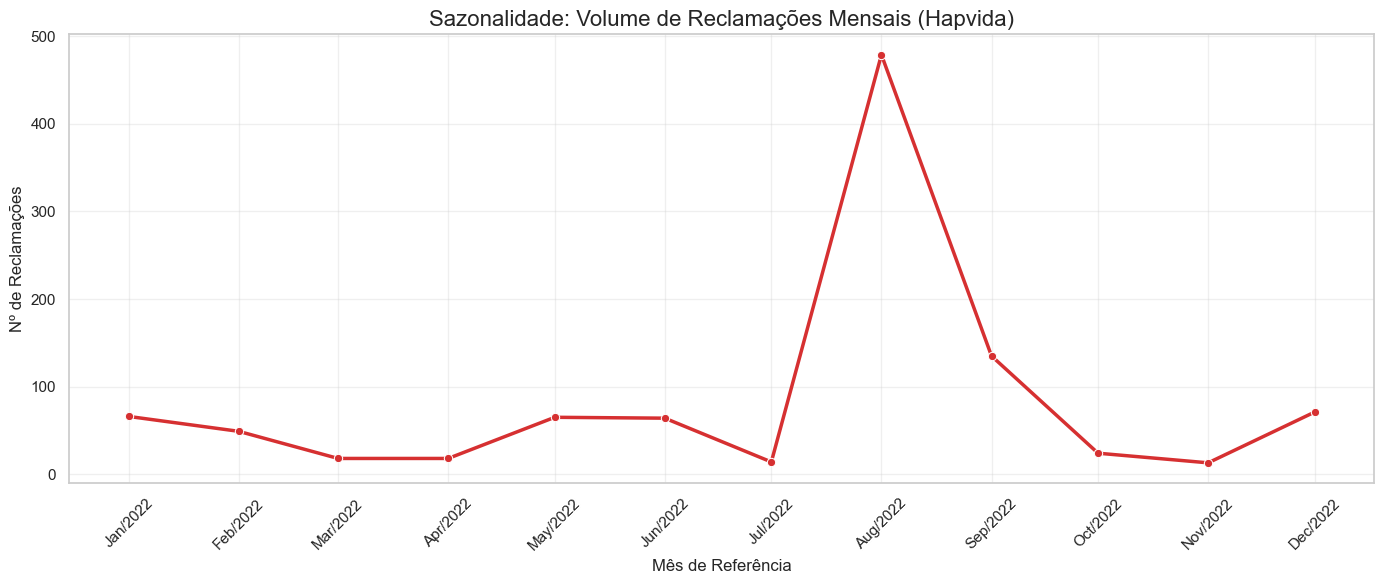

In [16]:
df['DATA'] = pd.to_datetime(df['DATA'])
configurar_estilo()

plotar_ranking_cidades(df)
plotar_sazonalidade(df)

## KPIs Obrigatorios para o Dashboard

Nesta secao, sao geradas as evidencias de: serie temporal com media movel, mapa geografico com seletor de ano e distribuicao de tamanho de texto por STATUS.


In [17]:
from src.visualizacao import (
    plotar_serie_temporal_media_movel,
    plotar_mapa_geografico_por_ano,
    plotar_distribuicao_tamanho_texto_status,
)


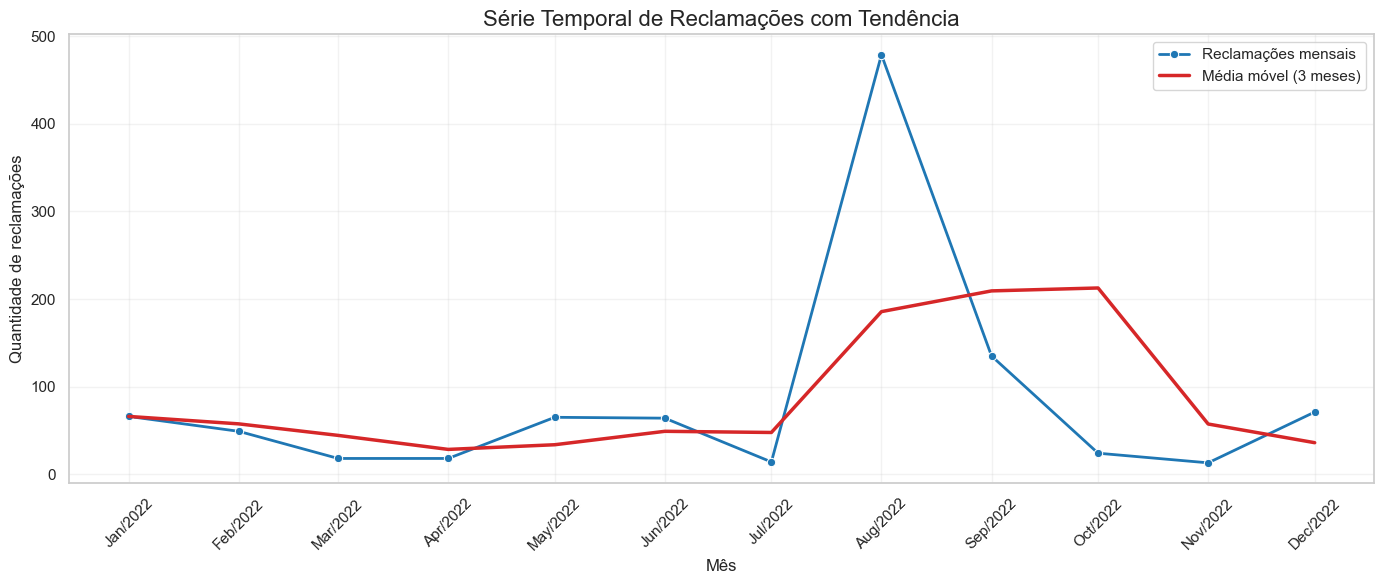

In [18]:
plotar_serie_temporal_media_movel(df, janela=3)


In [19]:
fig_mapa = plotar_mapa_geografico_por_ano(df)
fig_mapa.show()


In [20]:
fig_box = plotar_distribuicao_tamanho_texto_status(df, tipo='boxplot')
fig_box.show()

fig_hist = plotar_distribuicao_tamanho_texto_status(df, tipo='histograma', bins=25)
fig_hist.show()


## Evolução da Taxa de Omissão / Negligência

Esta KPI mostra os clientes que foram "abandonados". É um indicador importante pois, quando muito alto no Reclame Aqui, prejudica significativamente a reputação da empresa.

**Como calcular:** `(Total de Reclamações com STATUS = 'Não respondida' / Total de Reclamações) * 100`

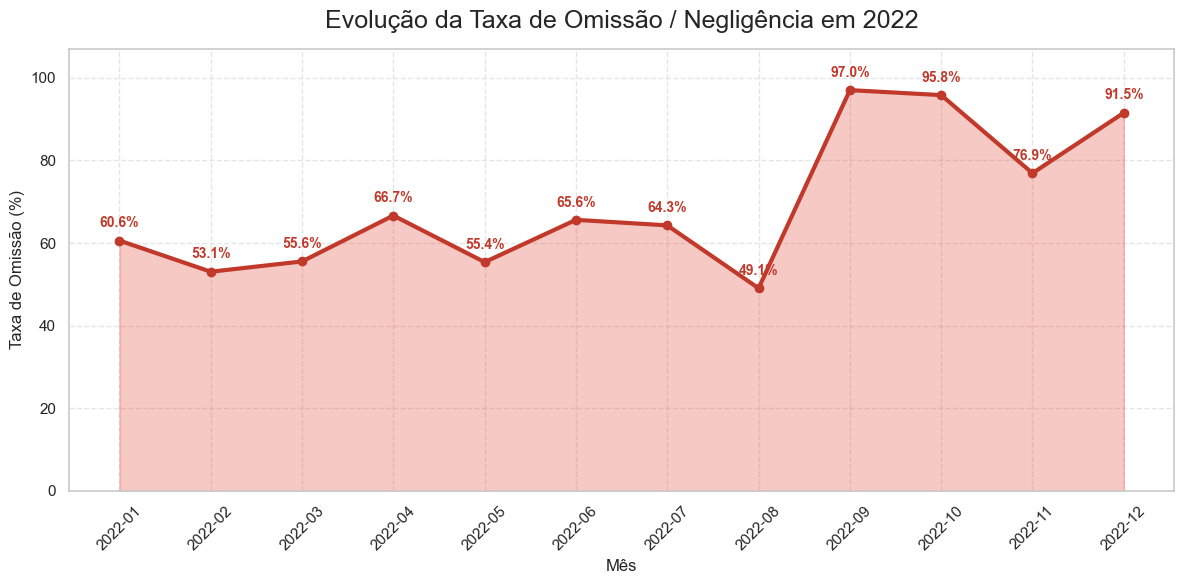

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# Filtrar para o ano de 2022
df_2022 = df[df['DATA'].dt.year == 2022].copy()

if df_2022.empty:
    print("Não há dados para o ano de 2022 no dataset.")
else:
    # Extrair o Mês/Ano
    df_2022['MES'] = df_2022['DATA'].dt.to_period('M')
    
    # Calcular totais por mês
    total_reclamacoes = df_2022.groupby('MES').size()
    
    # Calcular total de não respondidas por mês
    nao_respondidas = df_2022[df_2022['STATUS'] == 'Não respondida'].groupby('MES').size()
    
    # Consolidar em um DataFrame com preenchimento de zeros onde faltar dado
    df_taxa = pd.DataFrame({'Total': total_reclamacoes, 'Nao Respondida': nao_respondidas}).fillna(0)
    
    # Calcular a Taxa de Omissão em %
    df_taxa['Taxa de Omissao (%)'] = (df_taxa['Nao Respondida'] / df_taxa['Total']) * 100
    
    # Converter o índice para string para exibição correta no eixo X
    df_taxa.index = df_taxa.index.astype(str)
    
    # Criar a figura para o gráfico de área
    plt.figure(figsize=(12, 6))
    
    # Preencher a área (gráfico de área)
    plt.fill_between(df_taxa.index, df_taxa['Taxa de Omissao (%)'], color="#e74c3c", alpha=0.3)
    
    # Linha demarcando topo da área
    plt.plot(df_taxa.index, df_taxa['Taxa de Omissao (%)'], color="#c0392b", linewidth=3, marker='o')
    
    # Estilização do gráfico
    plt.title('Evolução da Taxa de Omissão / Negligência em 2022', fontsize=18, pad=15)
    plt.xlabel('Mês', fontsize=12)
    plt.ylabel('Taxa de Omissão (%)', fontsize=12)
    plt.xticks(rotation=45)
    
    # Ajustar Limites do eixo Y
    y_max = max(100, df_taxa['Taxa de Omissao (%)'].max() + 10) if not df_taxa.empty else 100
    plt.ylim(0, y_max)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    
    # Anotar valores exatos em cada ponto
    for i, taxa in enumerate(df_taxa['Taxa de Omissao (%)']):
        plt.text(i, taxa + 2.5, f"{taxa:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold', color="#c0392b")
        
    plt.show()

### 1. Configuração do Ambiente e Leitura dos Dados
Nesta etapa inicial, preparamos o ambiente para a análise exploratória:

* *Importação de Bibliotecas:* Carregamos o *Pandas* para manipulação de tabelas e as bibliotecas *Seaborn/Matplotlib* para futuras visualizações gráficas.
* *Leitura da Base:* O comando pd.read_csv localiza e carrega o arquivo de dados limpos para a memória.
* *Inspeção Inicial:* Selecionamos as colunas estratégicas (UF, STATUS, TIPO_SERVICO e PROBLEMA) e utilizamos o .head() para validar rapidamente se a estrutura dos dados foi carregada corretamente.


In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/RECLAMEAQUI_HAPVIDA_LIMPO.csv')

print(df[['UF', 'STATUS', 'TIPO_SERVICO', 'PROBLEMA']].head())

   UF          STATUS TIPO_SERVICO  \
0  PE  Não respondida  AUTORIZAÇÃO   
1  BA  Não respondida       OUTROS   
2  PE      Respondida  ATENDIMENTO   
3  GO  Não respondida  AUTORIZAÇÃO   
4  CE      Respondida  AGENDAMENTO   

                                            PROBLEMA  
0                                 DEMORA NA EXECUÇÃO  
1                      QUALIDADE DO SERVIÇO PRESTADO  
2  DEMORA PARA AUTORIZAÇÃO DE CONSULTAS, EXAMES E...  
3                                 DEMORA NA EXECUÇÃO  
4   DIFICULDADE PARA AGENDAMENTO DE EXAMES-CONSULTAS  


### 2. Análise de Frequência e Métricas de Engajamento
Nesta etapa, extraímos as primeiras estatísticas descritivas para entender o comportamento das reclamações:

* *Identificação de Padrões:* Utilizamos o método .value_counts().head(5) para listar os 5 tipos de problemas mais recorrentes e as 5 regiões (UF) com maior volume de registros.
* *Engenharia de Dados (Feature Engineering):* Criamos uma nova coluna chamada TAMANHO_RELATO, que calcula a quantidade de caracteres em cada descrição para medir a extensão das queixas.
* *Agrupamento por Status:* Calculamos a média de caracteres dos relatos agrupados pelo STATUS da reclamação. Isso ajuda a verificar, por exemplo, se reclamações não resolvidas tendem a ter textos mais longos ou detalhados.


In [24]:
print("--- 📊 TOP 5 PROBLEMAS MAIS COMUNS ---")
print(df['PROBLEMA'].value_counts().head(5))

print("\n--- 📍 VOLUME DE RECLAMAÇÕES POR UF (TOP 5) ---")
print(df['UF'].value_counts().head(5))

df['TAMANHO_RELATO'] = df['DESCRICAO'].astype(str).apply(len)
media_caracteres = df.groupby('STATUS')['TAMANHO_RELATO'].mean().sort_values(ascending=False)

print("\n--- ✍️ MÉDIA DE CARACTERES POR STATUS ---")
print(media_caracteres)

--- 📊 TOP 5 PROBLEMAS MAIS COMUNS ---
PROBLEMA
DIFICULDADE PARA AGENDAMENTO DE EXAMES-CONSULTAS                         229
REDE DE ATENDIMENTO, DIFICULDADE PARA AGENDAMENTO DE EXAMES-CONSULTAS     84
DEMORA PARA AUTORIZAÇÃO DE CONSULTAS, EXAMES E CIRURGIAS                  66
QUALIDADE DO SERVIÇO PRESTADO                                             55
MAU ATENDIMENTO DO PRESTADOR DE SERVIÇO                                   48
Name: count, dtype: int64

--- 📍 VOLUME DE RECLAMAÇÕES POR UF (TOP 5) ---
UF
CE    212
PE    173
BA    155
SP    140
GO     91
Name: count, dtype: int64

--- ✍️ MÉDIA DE CARACTERES POR STATUS ---
STATUS
Não respondida    494.868545
Em réplica        438.611111
Resolvido         392.537313
Respondida        380.180812
Não resolvido     337.333333
Name: TAMANHO_RELATO, dtype: float64


### 3. Análise Cruzada e Visualização de Eficiência por Região
Nesta etapa, realizamos um cruzamento de dados para identificar o desempenho do atendimento em diferentes estados:

* *Tabela de Contingência (Crosstab):* Utilizamos o pd.crosstab para cruzar as colunas UF e STATUS. A normalização pelo índice (normalize='index') transforma os valores brutos em porcentagens (0 a 100), permitindo uma comparação justa entre estados com volumes de reclamações diferentes.
* *Foco em Pendências:* Ordenamos os dados de forma decrescente pela coluna "Não respondida" para destacar as 10 regiões com os maiores gargalos de atendimento.
* *Visualização Gráfica:* Geramos um *Gráfico de Barras Empilhadas (Stacked Bar Chart)*. Essa visualização é ideal para observar a proporção de cada status dentro de cada estado, facilitando a identificação visual de onde a eficiência é menor (indicada por cores mais críticas).


<Figure size 1200x600 with 0 Axes>

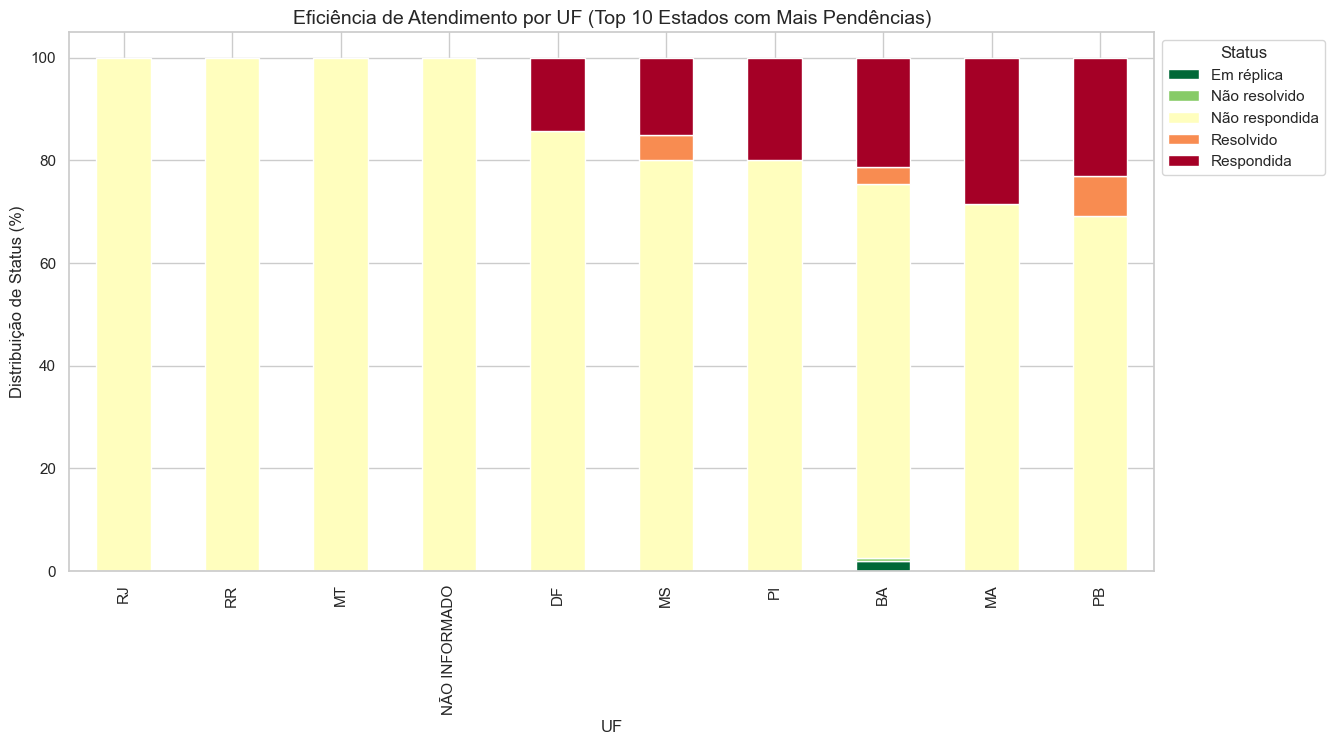

In [25]:
cruzamento_uf = pd.crosstab(df['UF'], df['STATUS'], normalize='index') * 100

cruzamento_uf = cruzamento_uf.sort_values(by='Não respondida', ascending=False).head(10)

plt.figure(figsize=(12, 6))
cruzamento_uf.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='RdYlGn_r')
plt.title('Eficiência de Atendimento por UF (Top 10 Estados com Mais Pendências)', fontsize=14)
plt.ylabel('Distribuição de Status (%)')
plt.legend(title='Status', bbox_to_anchor=(1, 1))
plt.show()

### 4. Correlação entre Serviços e Eficiência (Mapa de Calor)
Nesta seção, utilizamos uma abordagem visual de matriz para identificar gargalos em serviços específicos:

* *Matriz de Percentuais:* Novamente utilizamos o pd.crosstab com normalização para converter a contagem bruta em percentuais, o que permite comparar de forma justa serviços com volumes de queixas muito diferentes.
* *Mapa de Calor (Heatmap):* O comando sns.heatmap traduz os números em intensidades de cor (paleta "YlOrBr" - Amarelo, Laranja e Marrom). Isso facilita a identificação imediata de "pontos quentes", ou seja, tipos de serviço que possuem uma taxa de não resposta ou pendência acima da média.
* *Anotações e Formatação:* O parâmetro annot=True insere os valores exatos dentro de cada célula, e o fmt='.1f' garante que as porcentagens sejam exibidas com apenas uma casa decimal, mantendo o gráfico limpo e legível.

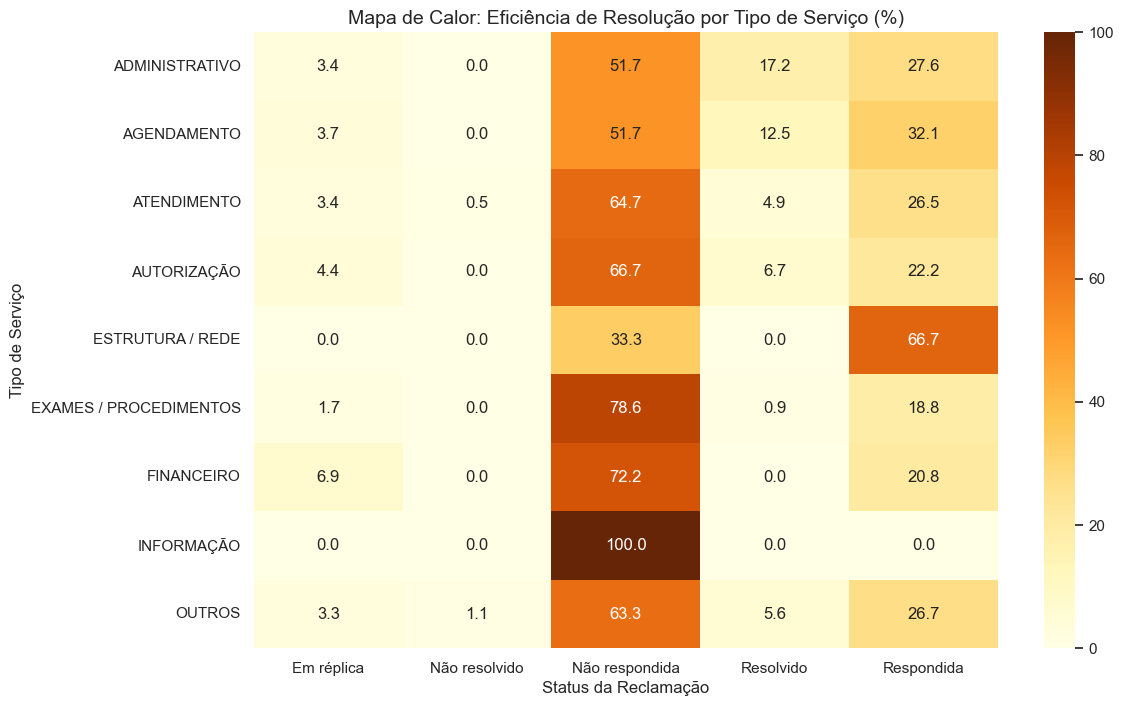

In [26]:
cruzamento_servico = pd.crosstab(df['TIPO_SERVICO'], df['STATUS'], normalize='index') * 100

plt.figure(figsize=(12, 8))
sns.heatmap(cruzamento_servico, annot=True, cmap="YlOrBr", fmt='.1f')
plt.title('Mapa de Calor: Eficiência de Resolução por Tipo de Serviço (%)', fontsize=14)
plt.xlabel('Status da Reclamação')
plt.ylabel('Tipo de Serviço')
plt.show()